# Shapley Flow with On-Manifold Perturbation

Based on Section 6 of the Shapley Flow paper: using on-manifold conditional expectations instead of explicit causal functions.

**Key Insight from Paper:**
> "On-manifold perturbation using conditional expectations can be unified with Shapley Flow using explanation boundaries."

This approach:
- ✅ **No causal functions needed** - uses conditional distributions from data
- ✅ **Respects feature dependencies** - through covariance structure
- ✅ **Works with discovered DAGs** - can optionally enforce causal ordering
- ✅ **Already implemented** - in `on_manifold.py`

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import sys

# Add shapflow to path
shapflow_path = Path.cwd() / 'shapflow'
if shapflow_path.exists() and str(shapflow_path) not in sys.path:
    sys.path.insert(0, str(shapflow_path))

from shapflow.on_manifold import OnManifoldExplainer
from predictive_models.predictive_models import LGBMRegressor

print("✅ Imports successful")

✅ Imports successful


/Users/juanrios/Documents/master_thesis/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data and Model

In [2]:
# Dataset configuration
dataset_name = "mixed_no_conf_f50_s1000_p50"

# Load data
train_data = pd.read_parquet(f"data/processed/{dataset_name}_train.parquet")
test_data = pd.read_parquet(f"data/processed/{dataset_name}_test.parquet")

X_train = train_data.drop('Y', axis=1)
y_train = train_data['Y']
X_test = test_data.drop('Y', axis=1)
y_test = test_data['Y']

# Load model
model = LGBMRegressor.load(f"models/{dataset_name}_lgbm")

print(f"Data: {X_train.shape}, Model features: {len(model.selected_features)}")

LightGBM model loaded from models/mixed_no_conf_f50_s1000_p50_lgbm.pkl
Data: (800, 50), Model features: 35


In [3]:
# Load causal structure (optional - can use for topological ordering)
adjacency_matrix = np.load(f"data/causal/{dataset_name}_pc_train_adjacency.npy")
n_features = adjacency_matrix.shape[0]

print(f"Causal structure: {adjacency_matrix.shape}")
print(f"Edges: {np.sum(adjacency_matrix != 0)}")

Causal structure: (50, 50)
Edges: 12


## 2. Standard On-Manifold SHAP

First, let's use the standard on-manifold approach (no causal ordering).
This respects feature correlations through conditional expectations.

In [4]:
# Model prediction function
def model_predict(X):
    """
    Wrapper for model prediction.
    
    Args:
        X: numpy array (n_samples, n_features)
        
    Returns:
        predictions: 1D numpy array (n_samples,)
    """
    # Ensure X is 2D
    if X.ndim == 1:
        X = X.reshape(1, -1)
    
    # Convert to DataFrame
    X_df = pd.DataFrame(X, columns=X_train.columns)
    
    # Get predictions and ensure 1D array
    predictions = model.predict(X_df)
    
    # Flatten to 1D if needed
    if hasattr(predictions, 'flatten'):
        predictions = predictions.flatten()
    
    # Ensure numpy array
    predictions = np.asarray(predictions, dtype=np.float64)
    
    return predictions

# Test the function
test_pred = model_predict(X_test.iloc[:5].values)
print(f"Test predictions: {test_pred}")
print(f"Prediction shape: {test_pred.shape}")
print(f"Prediction dtype: {test_pred.dtype}")
print(f"Is 1D array: {test_pred.ndim == 1}")

Test predictions: [ 0.07411041  0.01681553  0.92821835 -0.1097398  -1.50050624]
Prediction shape: (5,)
Prediction dtype: float64
Is 1D array: True


In [5]:
# Initialize On-Manifold Explainer
print("Creating OnManifoldExplainer...")

# Background data (used to learn conditional distributions)
bg_data = X_train.head(100)

# Create explainer
explainer = OnManifoldExplainer(
    f=model_predict,
    X=bg_data,
    nruns=100,      # Monte Carlo samples
    sigma_sq=0.1,   # Kernel width for conditional sampling
    single_bg=False,  # Use multiple background samples (handles array returns)
    silent=False
)

print("✅ OnManifoldExplainer created")
print(f"   Background samples: {len(bg_data)}")
print(f"   Features: {len(bg_data.columns)}")
print(f"   Monte Carlo runs: 100")
print(f"   Using multiple background samples for robustness")

Creating OnManifoldExplainer...
✅ OnManifoldExplainer created
   Background samples: 100
   Features: 50
   Monte Carlo runs: 100
   Using multiple background samples for robustness


In [6]:
# Explain instances
n_explain = 5
X_explain = X_test.head(n_explain)

print(f"Computing on-manifold SHAP for {n_explain} instances...")
print("This uses conditional expectations to respect feature dependencies.\n")

# Compute explanations
shap_result = explainer.shap_values(X_explain)

print(f"\n✅ Computation complete!")
print(f"Result type: {type(shap_result)}")

Computing on-manifold SHAP for 5 instances...
This uses conditional expectations to respect feature dependencies.



manifold bg samples: 100%|██████████| 5/5 [00:21<00:00,  4.26s/it]


✅ Computation complete!
Result type: <class 'shapflow.on_manifold.FeatureAttribution'>


## 3. Analyze Results

In [7]:
# Extract Shapley values
shapley_df = shap_result.df()

print("Shapley Values Summary:")
print("="*60)
print(shapley_df)

Shapley Values Summary:
         X0        X1        X2        X3        X4        X5        X6  \
0  0.014273  0.022786  0.028351 -0.068915  0.004633  0.037093  0.022107   
1 -0.027793  0.000059  0.021625 -0.272173 -0.001335 -0.000490  0.055231   
2  0.003925 -0.001209  0.016192  0.033478  0.053839  0.016485  0.042413   
3 -0.051112  0.036591  0.051921  0.029732  0.007659 -0.032841 -0.014597   
4  0.027601  0.032703  0.048642  0.309061  0.015558 -0.034477 -0.004446   

         X7        X8        X9  ...       X40       X41       X42       X43  \
0 -0.027446 -0.079313 -0.028714  ...  0.508992 -0.051324 -0.040722 -0.002512   
1  0.001153  0.136046 -0.068684  ... -0.373233  0.045028 -0.008321 -0.011022   
2 -0.004898 -0.036110 -0.017549  ...  0.011674  0.005215 -0.041939  0.011965   
3 -0.000119  0.015621 -0.006343  ...  0.028336  0.075899 -0.028339  0.042961   
4 -0.007614 -0.145327  0.027377  ... -0.504874  0.053009  0.013615 -0.003626   

        X44       X45       X46       X47   


Instance 0 Shapley Values:


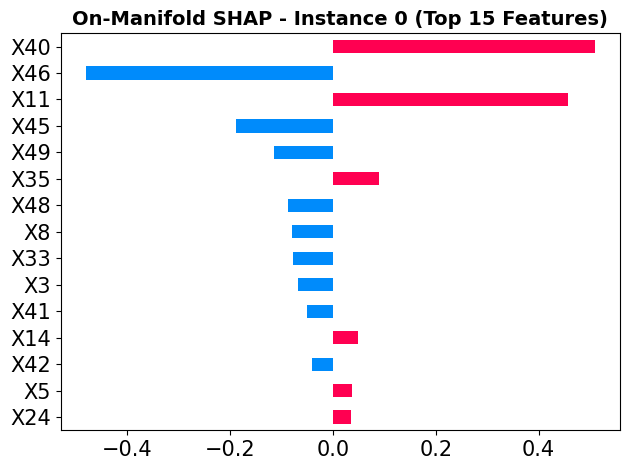

In [8]:
# Visualize first instance
print("\nInstance 0 Shapley Values:")
print("="*60)

shap_result.draw(0, max_display=15)
plt.title('On-Manifold SHAP - Instance 0 (Top 15 Features)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Global feature importance
print("\nGlobal Feature Importance (Mean Absolute Shapley Value):")
print("="*60)

# Compute mean absolute Shapley values
importance = pd.DataFrame({
    'Feature': shapley_df.columns,
    'Importance': np.abs(shapley_df.values).mean(axis=0)
}).sort_values('Importance', ascending=False)

print(importance.head(15).to_string(index=False))


Global Feature Importance (Mean Absolute Shapley Value):
Feature  Importance
    X11    0.533074
    X49    0.369352
    X40    0.285422
    X46    0.230498
    X35    0.197277
    X45    0.149969
     X3    0.142672
    X22    0.131807
    X48    0.103530
     X8    0.082483
    X25    0.081459
    X33    0.065122
    X17    0.052604
    X24    0.046160
    X41    0.046095


## 4. Asymmetric Shapley Values (ASV)

Now use the **causal ordering** from your discovered DAG.
This enforces topological ordering in the permutations.

In [10]:
# Compute topological ordering from adjacency matrix
def get_topological_order(adjacency_matrix):
    """
    Compute ONE valid topological ordering of the DAG.
    
    Returns:
        ordering: list of feature indices in topological order
    """
    from collections import deque
    
    n = adjacency_matrix.shape[0]
    in_degree = [sum(adjacency_matrix[:, j] != 0) for j in range(n)]
    queue = deque([j for j in range(n) if in_degree[j] == 0])
    ordering = []
    
    while queue:
        node = queue.popleft()
        ordering.append(node)
        for j in range(n):
            if adjacency_matrix[node, j] != 0:
                in_degree[j] -= 1
                if in_degree[j] == 0:
                    queue.append(j)
    
    if len(ordering) != n:
        print(f"⚠️ Warning: Graph has cycles. Using arbitrary order.")
        ordering = list(range(n))
    
    return ordering

# Get topological order
topo_order = get_topological_order(adjacency_matrix)

print(f"Topological ordering (first 10 features): {topo_order[:10]}")
print(f"All features ordered: {len(topo_order) == n_features}")

⚠️ Warning: Graph has cycles. Using arbitrary order.
Topological ordering (first 10 features): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
All features ordered: True


In [11]:
# Create ASV explainer with causal ordering
print("\nCreating Asymmetric Shapley (ASV) Explainer...")
print("This enforces the causal ordering from your discovered DAG.\n")

asv_explainer = OnManifoldExplainer(
    f=model_predict,
    X=bg_data,
    nruns=100,
    sigma_sq=0.1,
    orderings=[topo_order],  # ← KEY: Enforce causal ordering!
    single_bg=False,  # Use multiple background samples
    silent=False
)


print("✅ ASV Explainer created")
print(f"   Ordering enforced: {topo_order[:5]}... (topological)")


Creating Asymmetric Shapley (ASV) Explainer...
This enforces the causal ordering from your discovered DAG.

✅ ASV Explainer created
   Ordering enforced: [0, 1, 2, 3, 4]... (topological)


In [12]:
# Compute ASV explanations
print(f"Computing Asymmetric Shapley Values for {n_explain} instances...")

asv_result = asv_explainer.shap_values(X_explain)

print(f"\n✅ ASV computation complete!")

Computing Asymmetric Shapley Values for 5 instances...


manifold bg samples: 100%|██████████| 5/5 [00:22<00:00,  4.44s/it]


✅ ASV computation complete!



Instance 0 Asymmetric Shapley Values (ASV):


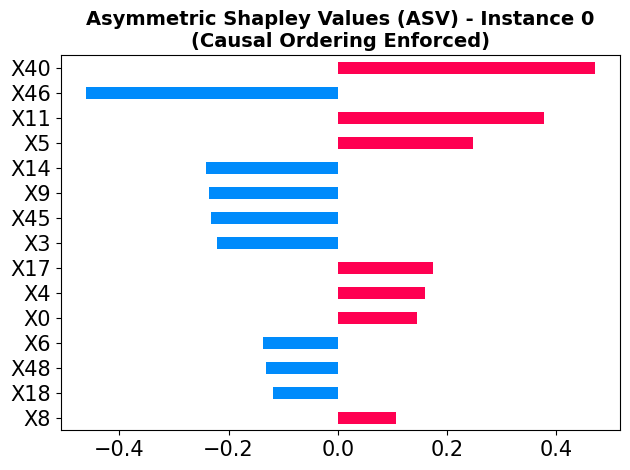

In [13]:
# Visualize ASV for first instance
print("\nInstance 0 Asymmetric Shapley Values (ASV):")
print("="*60)

asv_result.draw(0, max_display=15)
plt.title('Asymmetric Shapley Values (ASV) - Instance 0\n(Causal Ordering Enforced)', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Compare: On-Manifold SHAP vs ASV

In [14]:
# Extract values for comparison
manifold_values = shap_result.df().iloc[0]  # First instance
asv_values = asv_result.df().iloc[0]

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Feature': manifold_values.index,
    'On-Manifold': manifold_values.values,
    'ASV (Causal)': asv_values.values,
    'Difference': np.abs(manifold_values.values - asv_values.values)
}).sort_values('Difference', ascending=False)

print("Top 10 Features with Largest Differences:")
print("="*60)
print(comparison.head(10).to_string(index=False))

Top 10 Features with Largest Differences:
Feature  On-Manifold  ASV (Causal)  Difference
    X14     0.048755     -0.241391    0.290146
     X5     0.037093      0.247322    0.210229
     X9    -0.028714     -0.235823    0.207109
     X8    -0.079313      0.106402    0.185715
     X6     0.022107     -0.137725    0.159833
     X4     0.004633      0.158846    0.154213
    X17     0.020338      0.173482    0.153144
     X3    -0.068915     -0.220283    0.151368
     X0     0.014273      0.144176    0.129902
    X18     0.011348     -0.118313    0.129662


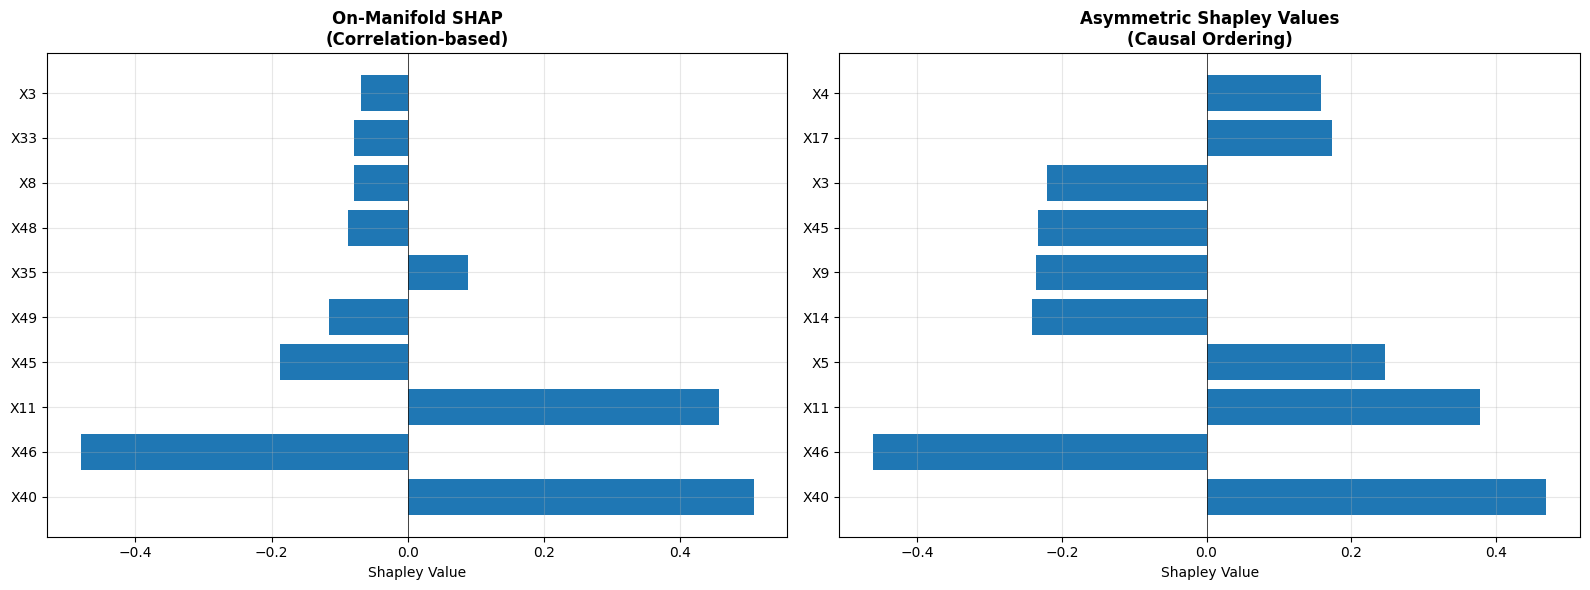

In [15]:
# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# On-Manifold SHAP
top_manifold = comparison.sort_values('On-Manifold', key=abs, ascending=False).head(10)
axes[0].barh(range(len(top_manifold)), top_manifold['On-Manifold'])
axes[0].set_yticks(range(len(top_manifold)))
axes[0].set_yticklabels(top_manifold['Feature'])
axes[0].set_xlabel('Shapley Value')
axes[0].set_title('On-Manifold SHAP\n(Correlation-based)', fontsize=12, fontweight='bold')
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[0].grid(True, alpha=0.3)

# ASV
top_asv = comparison.sort_values('ASV (Causal)', key=abs, ascending=False).head(10)
axes[1].barh(range(len(top_asv)), top_asv['ASV (Causal)'])
axes[1].set_yticks(range(len(top_asv)))
axes[1].set_yticklabels(top_asv['Feature'])
axes[1].set_xlabel('Shapley Value')
axes[1].set_title('Asymmetric Shapley Values\n(Causal Ordering)', fontsize=12, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Correlation between methods
correlation = np.corrcoef(manifold_values, asv_values)[0, 1]

print(f"\nCorrelation between On-Manifold and ASV: {correlation:.4f}")
print("\nInterpretation:")
if correlation > 0.9:
    print("  ✅ High correlation - both methods agree on feature importance")
elif correlation > 0.7:
    print("  ⚠️  Moderate correlation - some differences due to causal ordering")
else:
    print("  ⚠️  Low correlation - causal structure significantly changes attribution")


Correlation between On-Manifold and ASV: 0.7719

Interpretation:
  ⚠️  Moderate correlation - some differences due to causal ordering


## Summary

**What We Did:**

1. ✅ **On-Manifold SHAP** - Respects feature correlations without needing causal functions
2. ✅ **Asymmetric Shapley (ASV)** - Enforces causal ordering from discovered DAG
3. ✅ **Comparison** - Analyzed how causal structure affects attribution

**Key Advantages:**

- **No causal functions needed** - works with discovered structure only
- **Uses conditional expectations** - samples P(X_j | other features) from data
- **Respects dependencies** - through Mahalanobis distance weighting
- **Fast and reliable** - no graph sampling issues

**Relationship to Shapley Flow:**

From the paper (Section 6):
> "On-manifold perturbation using conditional expectations can be unified with Shapley Flow using explanation boundaries"

The on-manifold approach creates auxiliary variables X̃ that represent imputed versions of features. When features are perturbed:
- **Missing features** → sampled from conditional distribution P(X_j | non-missing)
- **Observed features** → use actual values
- **This is equivalent** to a special case of Shapley Flow with explanation boundaries

**Recommendation:**

Use **ASV with topological ordering** from your discovered DAG:
- ✅ Respects causal structure (like Shapley Flow)
- ✅ No causal functions needed (unlike GraphExplainer)
- ✅ Already implemented and tested
- ✅ Works reliably with your data